In [105]:
# LINEAR REGRESSION
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

def linear_regression(X, y, learning_rate=0.01, epochs=1000):
    n = len(X)
    w0 = 0
    w1 = 0

    for _ in range(epochs):
        y_pred = w0 + w1 * X
        dw0 = (-2 / n) * sum(y - y_pred)
        dw1 = (-2 / n) * sum(X * (y - y_pred))

        w0 -= learning_rate * dw0
        w1 -= learning_rate * dw1

    return w0, w1

In [106]:
# lets try on some random dataset

df = pd.read_csv('dataset/cardekho.csv')
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [108]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


<Axes: >

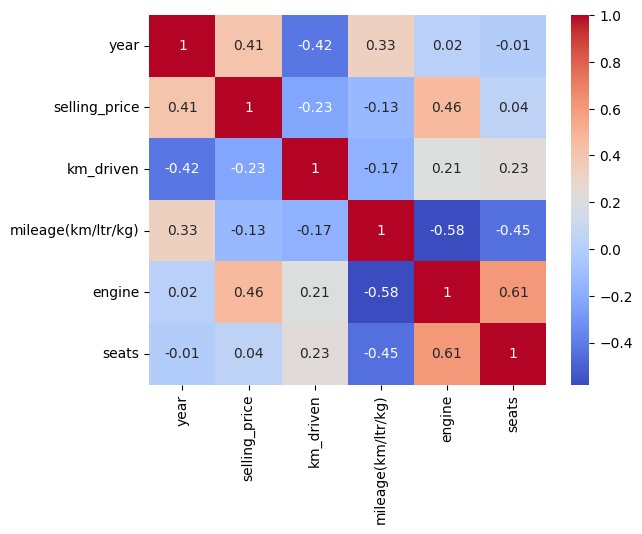

In [109]:
correlation_matrix = df[['year', 'selling_price', 'km_driven','mileage(km/ltr/kg)', 'engine', 'seats']].corr().round(2)
sb.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm')

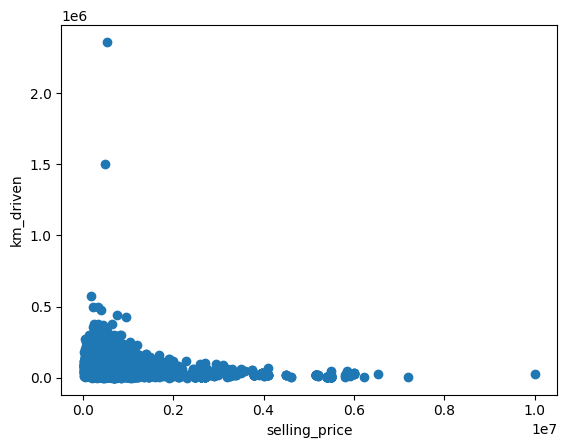

In [110]:
plt.scatter(df['selling_price'], df['km_driven'])
plt.xlabel('selling_price')
plt.ylabel('km_driven')
plt.show()

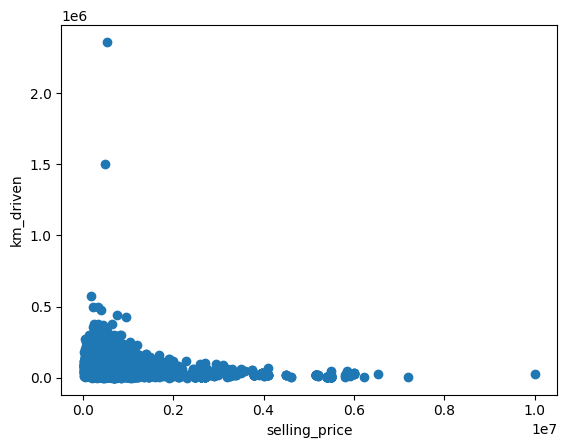

In [114]:
x = df.selling_price
y = df.km_driven

w0, w1 = linear_regression(x, y, learning_rate=0.00001, epochs=1000)
y_pred = w0 + w1 * x
plt.scatter(x=x, y=y)
plt.plot(x, y_pred, color='red')
plt.xlabel('selling_price')
plt.ylabel('km_driven')
plt.show()